# **Week 3 | Hands On**


**1.   Feature Engineering and Handling**

**2.   Outlier Handling (IQR and Business Perspective)**

**3.   Missing Value(Numerical and String Data)**

**4. Encoding (Label Encoder)**



**Feature Engineering**

*   Importing the prerequisite libraries
*   Set scalling and number of columns



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

**Outlier Handling - IQR Handling**



Importing the Sci-kit library

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

Displaying the dataset

In [3]:
df_california = pd.read_csv('DATASETS/california_dataset.csv')
df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Splitting the datasets into two (Train and Test)

In [4]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu
train_clfr, test_clfr = train_test_split(df_california, test_size=0.2, random_state=42)

#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

Calling the function to see the datasets index

In [5]:
df_california.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'house_price'],
      dtype='str')

**Plot Data Distribution and Outlier Handling (Assignment 1a)**

1. Lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv

2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']





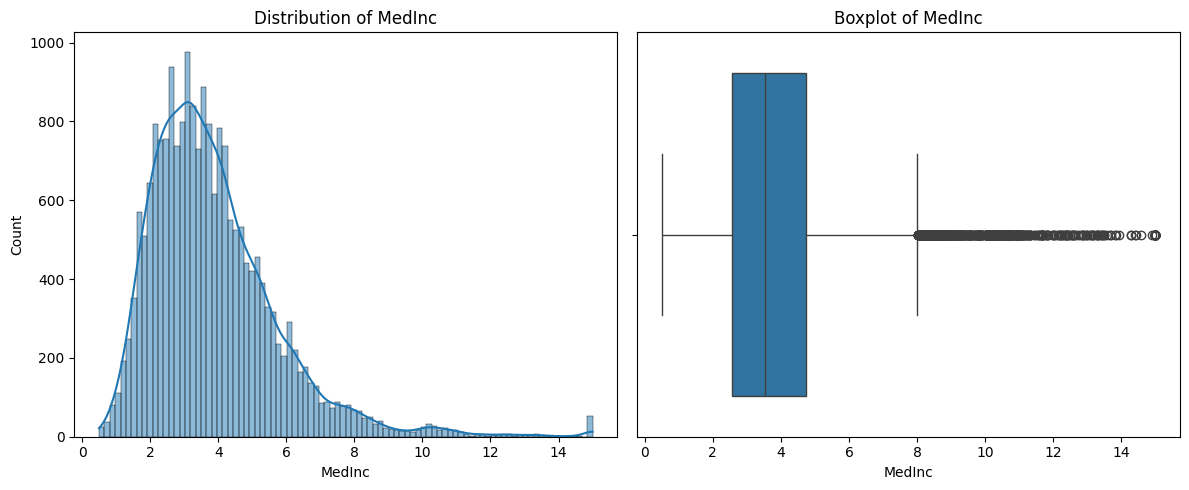

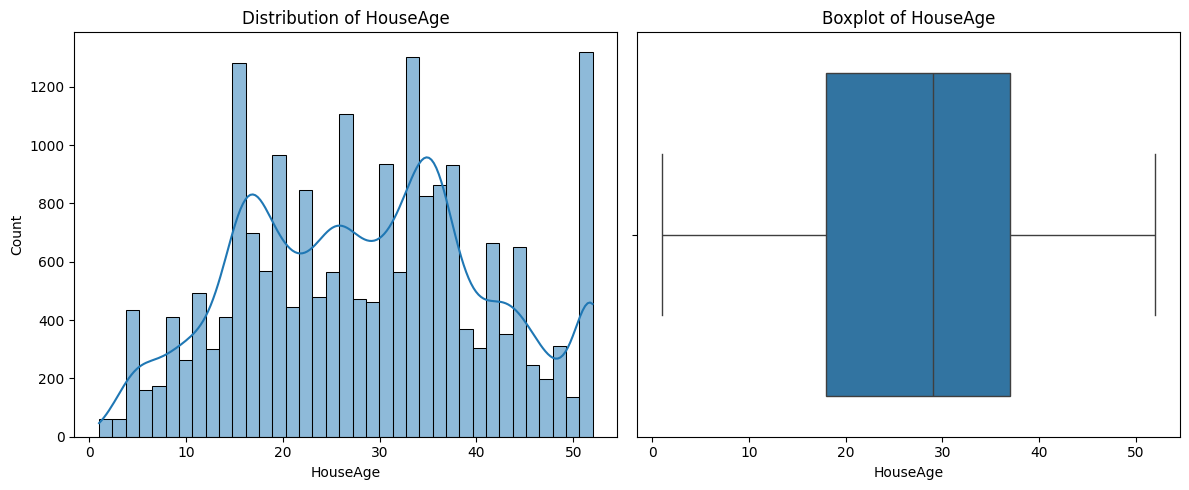

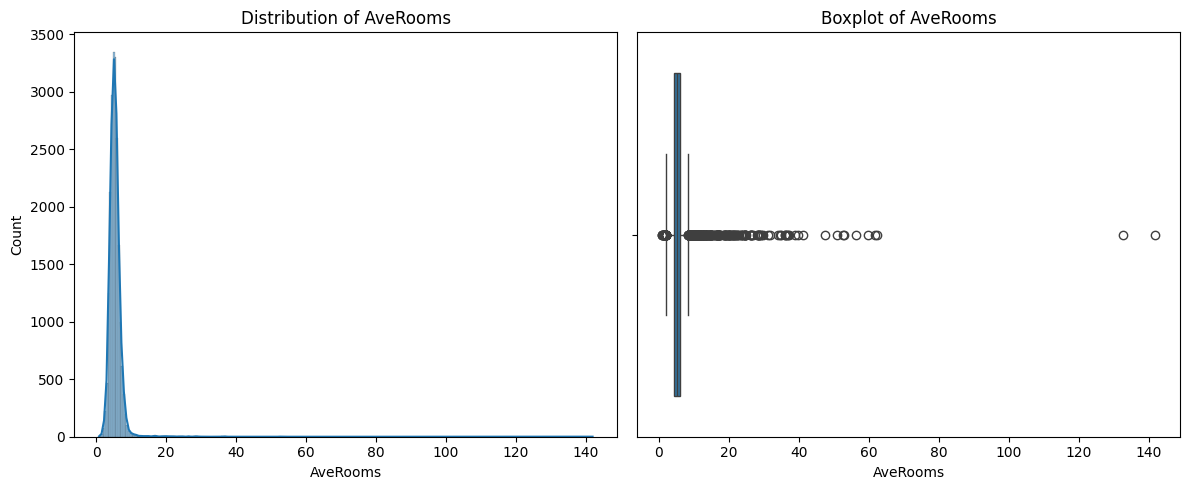

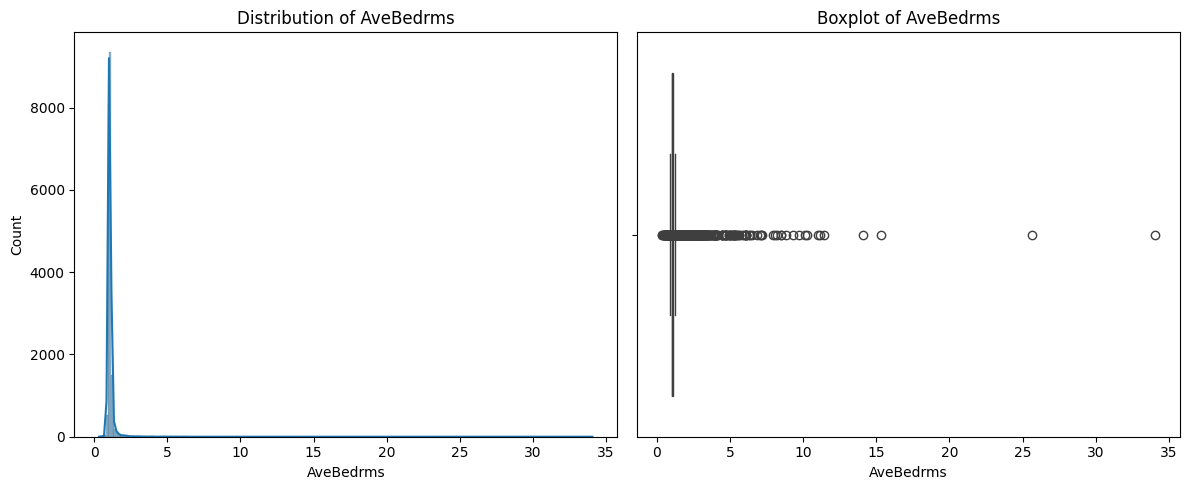

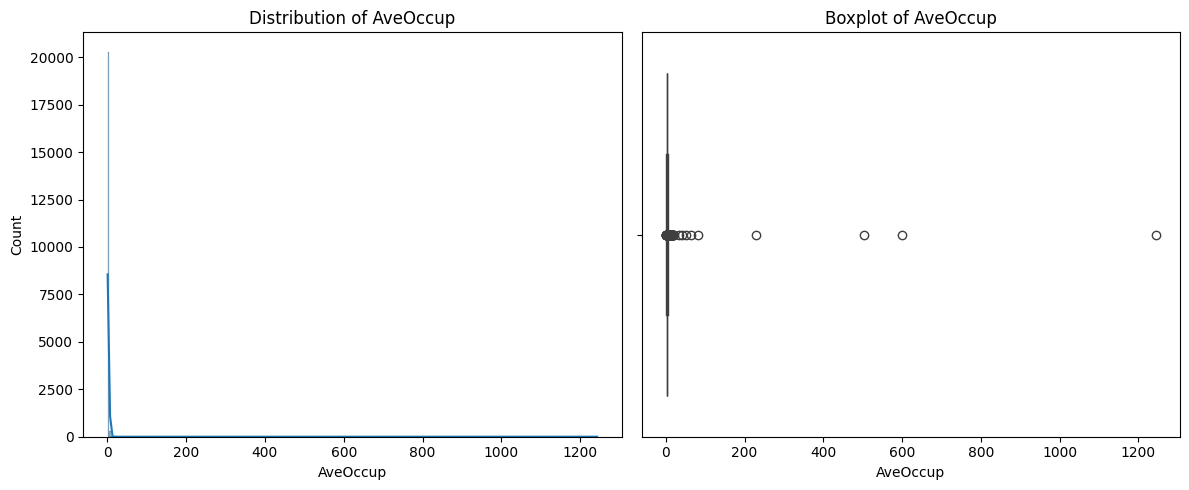

In [7]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
import matplotlib.pyplot as plt
import seaborn as sns
def check_plot(df, column_to_check):
    plt.figure(figsize=(12, 5))
    
    # Plot distribusi data
    plt.subplot(1, 2, 1)
    sns.histplot(df[column_to_check], kde=True)
    plt.title(f'Distribution of {column_to_check}')
    
    # Plot boxplot untuk melihat outlier
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[column_to_check])
    plt.title(f'Boxplot of {column_to_check}')
    
    plt.tight_layout()
    plt.show()
    
# Daftar nama kolom yang ingin Anda cek
columns_to_check = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# Loop untuk memanggil fungsi check_plot untuk setiap kolom
for col in columns_to_check:
    check_plot(df_california, col)

**IQR Outlier Handling (Assignment 1b)**

1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya

2. Dan cek distribusinya kembali





2.023219161170969
8.469878027106942


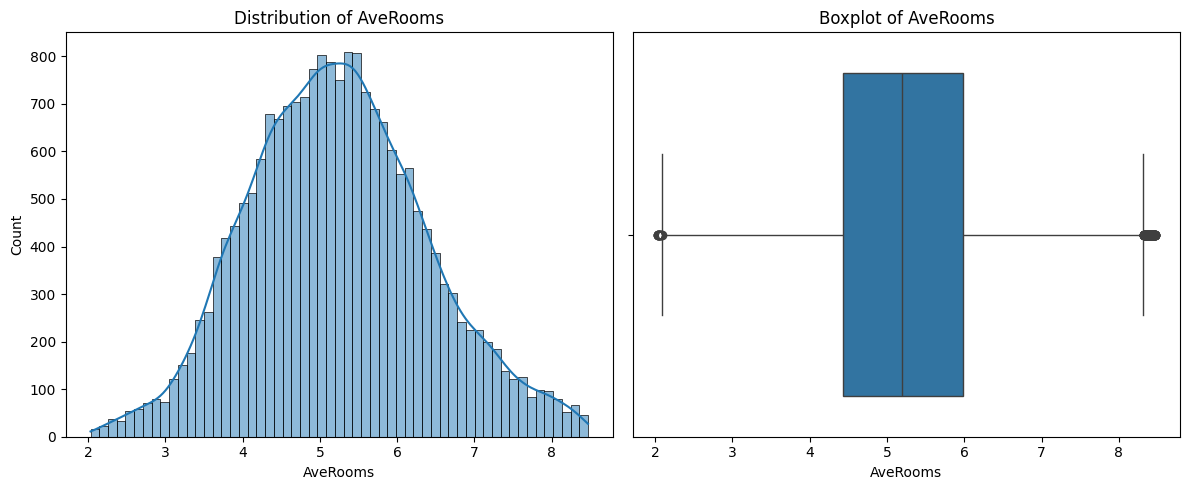

In [8]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_boundary = Q1 - 1.5 * IQR
    upper_boundary = Q3 + 1.5 * IQR

    print(lower_boundary)
    print(upper_boundary)
    
    # Menghapus outlier
    df_cleaned = df[(df[column] >= lower_boundary) & (df[column] <= upper_boundary)]
    
    return df_cleaned
### Dan cek distribusinya kembali
df_california_cleaned = handle_outliers_iqr(df_california, 'AveRooms')
check_plot(df_california_cleaned, 'AveRooms')

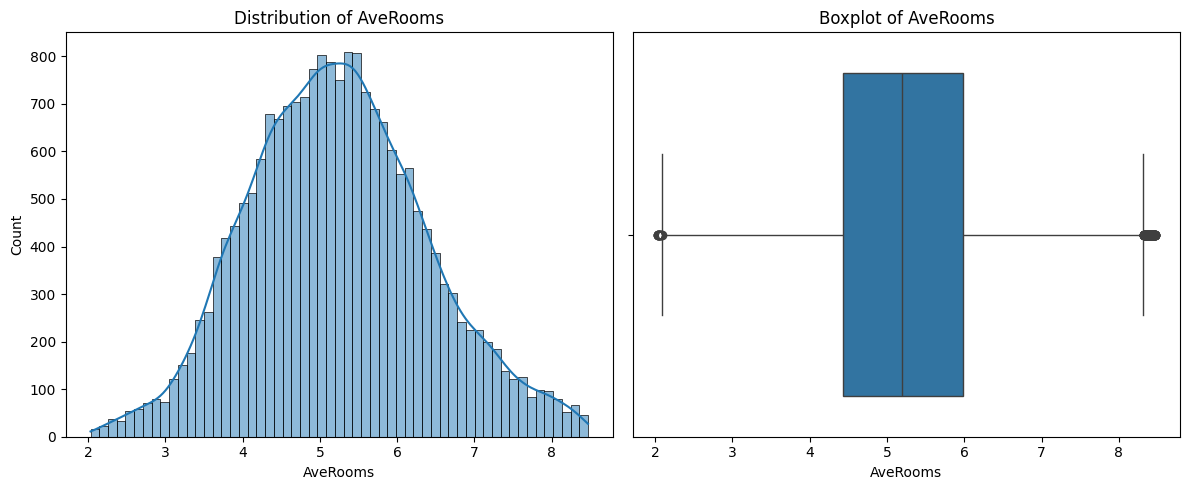

In [9]:
# Melakukan loop untuk mengecek distribusi tiap kolom
averooms = ['AveRooms']
for col in averooms: 
    check_plot(df_california_cleaned, col)

**Missing Value Handling**

Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.







In [10]:
df_company = pd.read_csv('DATASETS/company.csv')

**Aturan pada Missing Value**

1. Jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)

2. Jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**



In [11]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu
train,clfr = train_test_split(df_company, test_size=0.2, random_state=42)

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)



In [12]:
df_company.head()

,Revenue,Size,Rating,Headquarters
0,Unknown / Non-Applicable,1001 to 5000 employees,3.1,"New York, NY"
1,$1 to $2 billion (USD),5001 to 10000 employees,4.2,"Herndon, VA"
2,$100 to $500 million (USD),1001 to 5000 employees,3.8,"Boston, MA"
3,$100 to $500 million (USD),501 to 1000 employees,3.5,"Bad Ragaz, Switzerland"
4,Unknown / Non-Applicable,51 to 200 employees,2.9,"New York, NY"


**Missing Value Handling (Assignment 2 )**

1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?

2. Apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)

3. Jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?







In [13]:
# Define the variable first
df_company = pd.read_csv('DATASETS/company.csv')

In [14]:
df_company.isna().sum()

Revenue         0
Size            0
Rating          0
Headquarters    0
dtype: int64

In [21]:
for column in df_company.columns:
    print(f"============= {column} =================")
    display(df_company[column].value_counts())
    print() 

============= Revenue =================


Revenue
Unknown / Non-Applicable            213
$100 to $500 million (USD)           94
$10+ billion (USD)                   63
$2 to $5 billion (USD)               45
$10 to $25 million (USD)             41
$1 to $2 billion (USD)               36
$25 to $50 million (USD)             36
$50 to $100 million (USD)            31
$1 to $5 million (USD)               31
-1                                   27
$500 million to $1 billion (USD)     19
$5 to $10 million (USD)              14
Less than $1 million (USD)           14
$5 to $10 billion (USD)               8
Name: count, dtype: int64


============= Size =================


Size
51 to 200 employees        135
1001 to 5000 employees     104
1 to 50 employees           86
201 to 500 employees        85
10000+ employees            80
501 to 1000 employees       77
5001 to 10000 employees     61
-1                          27
Unknown                     17
Name: count, dtype: int64


============= Rating =================


Rating
 3.5    58
-1.0    50
 3.3    41
 4.0    41
 3.9    40
 3.8    39
 3.7    38
 5.0    36
 4.5    32
 3.6    31
 3.4    31
 4.2    29
 4.1    25
 4.4    24
 4.7    22
 3.2    21
 4.8    20
 2.9    14
 4.3    14
 3.1    12
 4.6    12
 4.9    11
 2.7    10
 3.0     7
 2.6     4
 2.8     3
 2.5     2
 2.2     1
 2.4     1
 2.3     1
 2.1     1
 2.0     1
Name: count, dtype: int64


============= Headquarters =================


Headquarters
New York, NY                 64
San Francisco, CA            31
Chicago, IL                  23
Boston, MA                   19
Reston, VA                   14
Mc Lean, VA                  13
Westminster, CO              12
Cambridge, MA                10
Cambridge, United Kingdom    10
Vienna, VA                    8
Herndon, VA                   7
Bedford, MA                   7
Saint Louis, MO               7
Washington, DC                7
Denver, CO                    7
Arlington, VA                 7
San Jose, CA                  7
Woodbine, MD                  7
Basel, Switzerland            6
Mountain View, CA             6
Chantilly, VA                 6
San Rafael, CA                6
San Antonio, TX               6
Princeton, NJ                 5
Bellevue, WA                  5
Rockville, MD                 5
Bethesda, MD                  5
Fairfax, VA                   5
Springfield, MA               5
Houston, TX                   5
Pittsburgh, PA             

In [16]:
# Checking the missing val in Rating
100 * len(df_company[df_company['Rating']==-1]) / len(df_company)

7.440476190476191

In [17]:
# Checking the missing val in Size
100 * len(df_company[df_company['Size'].isin(['-1','Unknown'])]) / len(df_company)

6.5476190476190474

In [20]:
#Tulis jawaban missing value handling kolom Headquarters disini

# Checking the missing val in Headquarters
100 * len(df_company[df_company['Headquarters'].isin(['-1','Unknown','N/A'])]) / len(df_company)

0.0

In [19]:
#Replace the missing values in Headquarters with the mode
mode_headquarters = df_company['Headquarters'].mode()[0]
df_company['Headquarters'] = df_company['Headquarters'].replace(['-1','Unknown','N/A'], mode_headquarters)

**Encoder**

Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :

1. **One Hot Encoding (OHE)** : Lakukan pada kolom gender

2. **Label Encoding / Ordinal Encoding** : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.

3. **Mean Encoding** : Contract



In [22]:
df_churn = pd.read_csv('DATASETS/TelcoCustomerChurn.csv')
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
#Splitting terlebih dahulu
train_clfr, test_clfr = train_test_split(df_churn, test_size=0.2, random_state=42)

**Label Encoder (Assignment 3)**

1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines

2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts

3. Kemudian lakukan label Encoder

4. Notes : gunakan Telco-Customer-Churn.csv







In [24]:
# Mengganti nilai No internet service dengan No untuk kolom-kolom : ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection','OnlineBackup','OnlineSecurity','MultipleLines']
df_churn['StreamingMovies'] = df_churn['StreamingMovies'].replace({'No internet service':'No'})
df_churn['StreamingTV'] = df_churn['StreamingTV'].replace({'No internet service':'No'})
df_churn['TechSupport'] = df_churn['TechSupport'].replace({'No internet service':'No'})
df_churn['DeviceProtection'] = df_churn['DeviceProtection'].replace({'No internet service':'No'})
df_churn['OnlineBackup'] = df_churn['OnlineBackup'].replace({'No internet service':'No'})
df_churn['OnlineSecurity'] = df_churn['OnlineSecurity'].replace({'No internet service':'No'})
df_churn['MultipleLines'] = df_churn['MultipleLines'].replace({'No phone service':'No'})

In [25]:
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [26]:
# Mengecek hasil penggantian nilai
for col in ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection','OnlineBackup','OnlineSecurity','MultipleLines']:
    print(f"Value counts for {col}:")
    print(df_churn[col].value_counts())
    print()

Value counts for StreamingMovies:
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64

Value counts for StreamingTV:
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64

Value counts for TechSupport:
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64

Value counts for DeviceProtection:
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64

Value counts for OnlineBackup:
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64

Value counts for OnlineSecurity:
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64

Value counts for MultipleLines:
MultipleLines
No     4072
Yes    2971
Name: count, dtype: int64



In [40]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder
colums_to_encode = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection','OnlineBackup','OnlineSecurity','MultipleLines']

# Inisialisasi LabelEncoder
l_enc = LabelEncoder()

# Label encoding ke data train
for col in colums_to_encode:
    train_clfr[col] = l_enc.fit_transform(train_clfr[col])

# Label encoding ke data test
for col in colums_to_encode:
    test_clfr[col] = l_enc.fit_transform(test_clfr[col])

In [41]:
train_clfr.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2142,4223-BKEOR,Female,0,No,Yes,21,Yes,0,DSL,2,0,2,0,0,2,One year,No,Mailed check,64.85,1336.8,No
1623,6035-RIIOM,Female,0,No,No,54,Yes,2,Fiber optic,0,2,0,0,2,2,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
6074,3797-VTIDR,Male,0,Yes,No,1,No,1,DSL,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,23.45,23.45,Yes
1362,2568-BRGYX,Male,0,No,No,4,Yes,0,Fiber optic,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,70.20,237.95,Yes
6754,2775-SEFEE,Male,0,No,Yes,0,Yes,2,DSL,2,2,0,2,0,0,Two year,Yes,Bank transfer (automatic),61.90,,No


In [42]:
test_clfr.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,1,DSL,0,0,0,0,0,0,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,2,No,1,1,1,1,1,1,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,0,No,1,1,1,1,1,1,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,0,Fiber optic,0,0,2,0,0,0,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,0,DSL,0,0,0,2,0,0,Two year,No,Bank transfer (automatic),50.55,3260.1,No
